<a href="https://colab.research.google.com/github/Shervinrtd/Chest_Xray/blob/main/Chest_Xray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
!pip install torch torchvision torchaudio
!pip install matplotlib seaborn scikit-learn
!pip install opencv-python

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device: cuda
GPU Name: Tesla T4


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = '/content/drive/MyDrive/deep_learning_project/chest_xray.zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

print(os.listdir('/content/chest_xray/chest_xray/train'))

['PNEUMONIA', 'NORMAL']


**Import Required Libraries**

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os

**Check GPU**

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


**Define Image Transformations**

In [21]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [22]:
train_dataset = datasets.ImageFolder(
    root='/content/chest_xray/chest_xray/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root='/content/chest_xray/chest_xray/val',
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root='/content/chest_xray/chest_xray/test',
    transform=test_transform
)

In [23]:
print(f"Number of images in train_dataset: {len(train_dataset)}")
print(f"Number of images in val_dataset: {len(val_dataset)}")
print(f"Number of images in test_dataset: {len(test_dataset)}")

Number of images in train_dataset: 5216
Number of images in val_dataset: 16
Number of images in test_dataset: 624


**Create DataLoaders**

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

**Visualize Images**

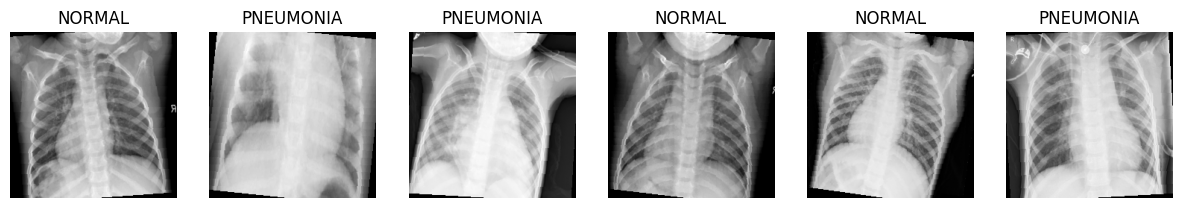

In [25]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(15,5))

for i in range(6):

    # Get the image tensor
    img_tensor = images[i]

    # Unnormalize (applied to all channels)
    img_tensor = (img_tensor * 0.5) + 0.5

    # Convert the tensor to a NumPy array, taking only one channel for grayscale display
    img_np = img_tensor[0].numpy()

    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(train_dataset.classes[labels[i]])
    axes[i].axis('off')

plt.show()

**Build the Baseline CNN**

In [47]:
class PneumoniaCNN(nn.Module):

    def __init__(self):
        super(PneumoniaCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, 2)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

**Initialize Model**

In [48]:
model = PneumoniaCNN().to(device)

print(model)

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=2, bias=True)
  )

**Define Loss and Optimizer**

In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

**Training Loop**

In [41]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # TRAINING
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # VALIDATION
        model.eval()

        val_running_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")
        print("-"*50)

    return train_losses, val_losses, train_accuracies, val_accuracies

**Training**

In [30]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch [1/5]
Train Loss: 0.2776 | Train Accuracy: 88.48%
Val Loss: 0.6658 | Val Accuracy: 68.75%
--------------------------------------------------
Epoch [2/5]
Train Loss: 0.1323 | Train Accuracy: 94.69%
Val Loss: 0.5600 | Val Accuracy: 68.75%
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.1150 | Train Accuracy: 95.84%
Val Loss: 1.0504 | Val Accuracy: 62.50%
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.1039 | Train Accuracy: 95.99%
Val Loss: 0.9385 | Val Accuracy: 62.50%
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.0943 | Train Accuracy: 96.51%
Val Loss: 0.7606 | Val Accuracy: 62.50%
--------------------------------------------------


**Evaluate on Test Set**

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

**Classification Report**

In [32]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      NORMAL       0.96      0.37      0.54       234
   PNEUMONIA       0.72      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.84      0.68      0.69       624
weighted avg       0.81      0.76      0.72       624



**Confusion Matrix**

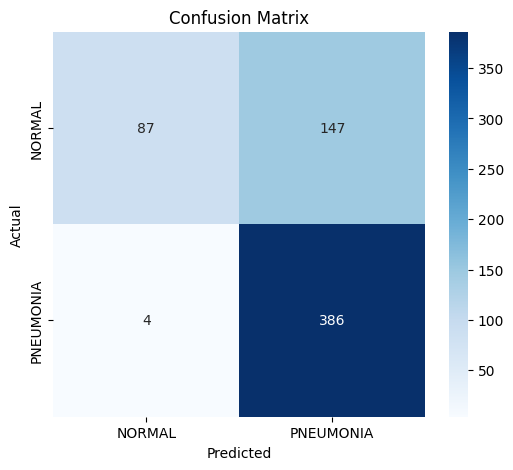

In [33]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Calculate Class Counts**

In [42]:
from collections import Counter

labels = train_dataset.targets

class_counts = Counter(labels)

print(class_counts)

Counter({1: 3875, 0: 1341})


**Create Class Weights**

In [43]:
num_normal = class_counts[0]
num_pneumonia = class_counts[1]

weights = torch.tensor([
    1.0 / num_normal,
    1.0 / num_pneumonia
], dtype=torch.float)

weights = weights.to(device)

print(weights)

tensor([0.0007, 0.0003], device='cuda:0')


**Replace Loss Function**

In [ ]:
model = PneumoniaCNN().to(device)

In [44]:
criterion = nn.CrossEntropyLoss(weight=weights)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

**Retrain**

In [45]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch [1/5]
Train Loss: 0.6931 | Train Accuracy: 73.41%
Val Loss: 0.6985 | Val Accuracy: 50.00%
--------------------------------------------------
Epoch [2/5]
Train Loss: 0.6931 | Train Accuracy: 73.56%
Val Loss: 0.6985 | Val Accuracy: 50.00%
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.6931 | Train Accuracy: 73.26%
Val Loss: 0.6985 | Val Accuracy: 50.00%
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.6931 | Train Accuracy: 73.14%
Val Loss: 0.6985 | Val Accuracy: 50.00%
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.6932 | Train Accuracy: 73.10%
Val Loss: 0.6985 | Val Accuracy: 50.00%
--------------------------------------------------


**relative balancing**

In [49]:
num_normal = class_counts[0]
num_pneumonia = class_counts[1]

total = num_normal + num_pneumonia

weight_normal = total / (2 * num_normal)
weight_pneumonia = total / (2 * num_pneumonia)

weights = torch.tensor(
    [weight_normal, weight_pneumonia],
    dtype=torch.float
).to(device)

print(weights)

tensor([1.9448, 0.6730], device='cuda:0')


In [ ]:
model = PneumoniaCNN().to(device)

In [50]:
criterion = nn.CrossEntropyLoss(weight=weights)

In [51]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [52]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)


Epoch [1/5]
Train Loss: 0.3854 | Train Accuracy: 81.15%
Val Loss: 0.7097 | Val Accuracy: 62.50%
--------------------------------------------------
Epoch [2/5]
Train Loss: 0.1804 | Train Accuracy: 93.39%
Val Loss: 0.5851 | Val Accuracy: 68.75%
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.1567 | Train Accuracy: 94.42%
Val Loss: 0.3996 | Val Accuracy: 81.25%
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.1307 | Train Accuracy: 95.30%
Val Loss: 0.7470 | Val Accuracy: 62.50%
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.1282 | Train Accuracy: 95.40%
Val Loss: 0.5107 | Val Accuracy: 68.75%
--------------------------------------------------


In [53]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [54]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      NORMAL       0.92      0.61      0.74       234
   PNEUMONIA       0.81      0.97      0.88       390

    accuracy                           0.83       624
   macro avg       0.86      0.79      0.81       624
weighted avg       0.85      0.83      0.83       624



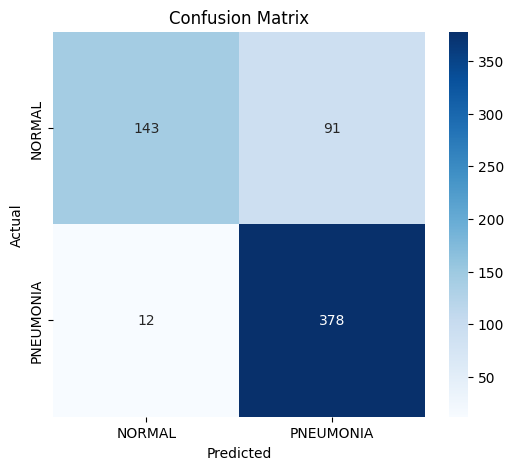

In [55]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Transfer Learning

**Import ResNet**

In [56]:
from torchvision import models

**Load Pretrained ResNet50**

In [57]:
resnet_model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


**Freeze Feature Extractor**

In [58]:
for param in resnet_model.parameters():
    param.requires_grad = False

In [59]:
num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

**Move Model to GPU**

In [60]:
resnet_model = resnet_model.to(device)

**Define Loss and Optimizer**

In [61]:
criterion = nn.CrossEntropyLoss(weight=weights)

In [62]:
optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

**Train ResNet**

In [63]:
train_losses_resnet, val_losses_resnet, train_acc_resnet, val_acc_resnet = train_model(
    resnet_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch [1/5]
Train Loss: 0.2832 | Train Accuracy: 87.48%
Val Loss: 0.3842 | Val Accuracy: 81.25%
--------------------------------------------------
Epoch [2/5]
Train Loss: 0.2420 | Train Accuracy: 90.66%
Val Loss: 0.6912 | Val Accuracy: 81.25%
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.2071 | Train Accuracy: 92.12%
Val Loss: 0.9388 | Val Accuracy: 75.00%
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.1922 | Train Accuracy: 92.33%
Val Loss: 0.4825 | Val Accuracy: 81.25%
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.2023 | Train Accuracy: 92.04%
Val Loss: 1.0126 | Val Accuracy: 68.75%
--------------------------------------------------


**Replace Training Function**

*   best model saving

*   validation monitoring



In [73]:
def train_model_with_checkpoint(model, train_loader, val_loader, criterion, optimizer, epochs=5):

    best_val_accuracy = 0

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # TRAINING
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # VALIDATION
        model.eval()

        val_running_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # SAVE BEST MODEL
        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            torch.save(model.state_dict(), "best_resnet_model.pth")

            print("Best model saved!")

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")
        print("-"*50)

    return train_losses, val_losses, train_accuracies, val_accuracies

**Unfreeze Last Layers**

In [64]:
for param in resnet_model.parameters():
    param.requires_grad = False

In [65]:
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

In [66]:
for param in resnet_model.fc.parameters():
    param.requires_grad = True

**Use Smaller Learning Rate**

In [67]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=0.0001
)

**Retrain**

In [75]:
train_losses_resnet_ft, val_losses_resnet_ft, train_acc_resnet_ft, val_acc_resnet_ft = train_model_with_checkpoint(
    resnet_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Best model saved!
Epoch [1/5]
Train Loss: 0.0372 | Train Accuracy: 98.89%
Val Loss: 0.0855 | Val Accuracy: 93.75%
--------------------------------------------------
Best model saved!
Epoch [2/5]
Train Loss: 0.0192 | Train Accuracy: 99.31%
Val Loss: 0.0955 | Val Accuracy: 100.00%
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.0246 | Train Accuracy: 99.23%
Val Loss: 0.0871 | Val Accuracy: 100.00%
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.0142 | Train Accuracy: 99.46%
Val Loss: 0.0158 | Val Accuracy: 100.00%
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.0233 | Train Accuracy: 99.31%
Val Loss: 0.0590 | Val Accuracy: 100.00%
--------------------------------------------------


**Load Best Model**

In [76]:
resnet_model.load_state_dict(torch.load("/content/best_resnet_model.pth"))

<All keys matched successfully>

**Generate Predictions**

In [77]:
resnet_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

**Classification Report**

In [78]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      NORMAL       0.98      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



**Confusion Matrix**

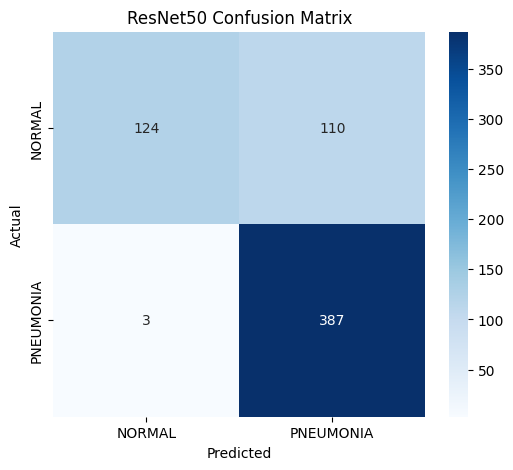

In [79]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")

plt.show()

In [80]:
torch.save(model.state_dict(), "best_weighted_cnn.pth")

In [81]:
import cv2
import numpy as np

**Load Best Weighted CNN**

In [83]:
model = PneumoniaCNN().to(device)

model.load_state_dict(torch.load("best_weighted_cnn.pth"))

model.eval()

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=2, bias=True)
  )

**Create Grad-CAM Class**

In [84]:
class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_image, target_class=None):

        output = self.model(input_image)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()

        loss = output[:, target_class]

        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam = cam.detach().cpu().numpy()

        cam = cv2.resize(cam, (224, 224))

        cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam

**Select Target Layer**

In [85]:
target_layer = model.features[-2]

grad_cam = GradCAM(model, target_layer)

**Get a Test Image**

In [86]:
image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

**Generate Heatmap**

In [87]:
cam = grad_cam.generate_cam(input_tensor)

**Convert Original Image**

In [88]:
original_image = image.permute(1, 2, 0).numpy()

original_image = (original_image * 0.5) + 0.5

original_image = np.clip(original_image, 0, 1)

**Overlay Heatmap**

In [89]:
heatmap = cv2.applyColorMap(
    np.uint8(255 * cam),
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

heatmap = heatmap / 255.0

overlay = heatmap * 0.4 + original_image * 0.6

**Display Results**

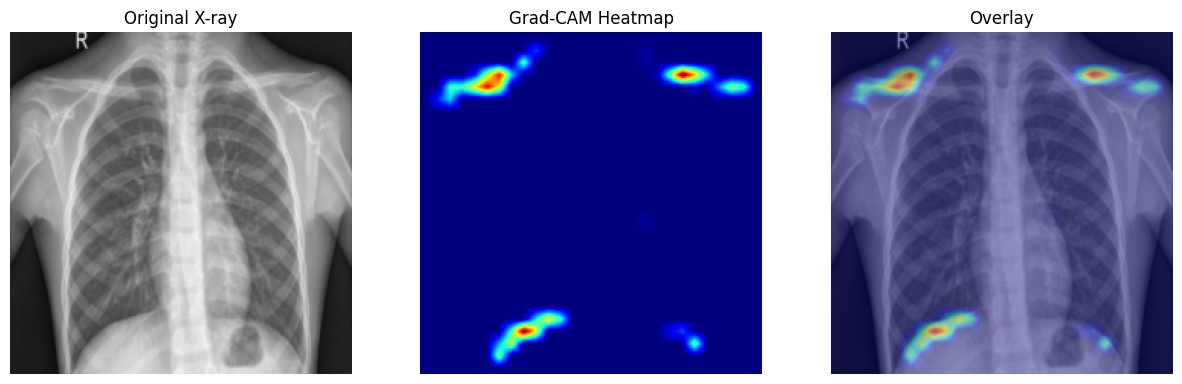

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(original_image)
axes[0].set_title("Original X-ray")
axes[0].axis('off')

axes[1].imshow(cam, cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.show()

**Loss Curve**

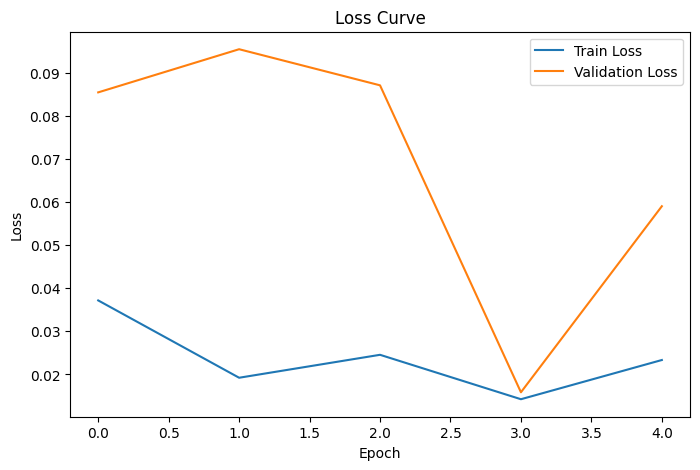

In [91]:
plt.figure(figsize=(8,5))

plt.plot(train_losses_resnet_ft, label='Train Loss')
plt.plot(val_losses_resnet_ft, label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

**Accuracy Curve**

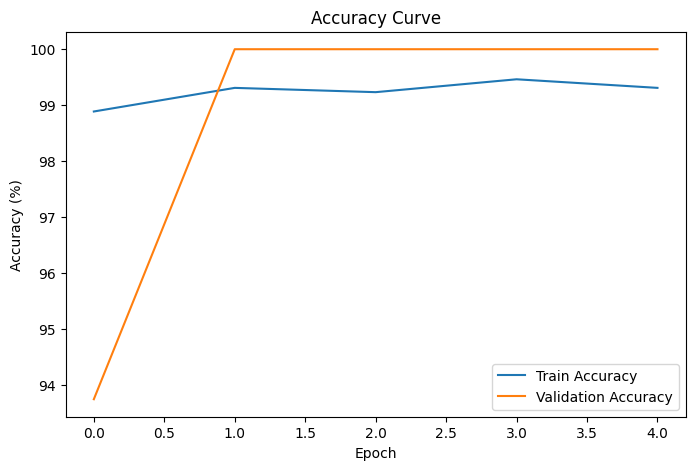

In [92]:
plt.figure(figsize=(8,5))

plt.plot(train_acc_resnet_ft, label='Train Accuracy')
plt.plot(val_acc_resnet_ft, label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.legend()

plt.show()